# SLX modeling

**Note**: This notebook requires the following data to be loaded:
- `gdf`: City geometries (from cities.geojson)
- `df_metrics_c`: City compactness metrics with cluster assignments
- `df_raw`: Cell-level data with bubble breaking, POI metrics, etc.


## Imports and Setup

In [ ]:
%cd /work/netmob24

In [1]:
import pandas as pd
import numpy as np
import geopandas as gpd
import os
import h3
from shapely.geometry import Polygon
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm
from mpl_toolkits.axes_grid1 import make_axes_locatable
from scipy.stats import norm
import json
import libpysal

## Helper Functions and Configuration

In [2]:
def weighted_median(values, weights):
    """Compute weighted median"""
    sorted_idx = np.argsort(values)
    sorted_vals = np.array(values)[sorted_idx]
    sorted_weights = np.array(weights)[sorted_idx]
    cum_weights = np.cumsum(sorted_weights)
    cutoff = 0.5 * sum(sorted_weights)
    return sorted_vals[cum_weights >= cutoff][0]

In [38]:
import matplotlib as mpl
import matplotlib.colors as mcolors
from matplotlib import font_manager
import pathlib

font_dir = pathlib.Path.home() / "fonts"

for f in font_dir.glob("*.ttf"):
    font_manager.fontManager.addfont(str(f))

def setup_mpl():

    mpl.rcParams.update({

        # -------------------
        # Fonts (publication safe)
        # -------------------
        "font.family": "Liberation Sans",
        "font.size": 7,          # base text

        "axes.labelsize": 8,
        "axes.titlesize": 8,
        "legend.fontsize": 7,
        "xtick.labelsize": 6,
        "ytick.labelsize": 6,

        # keep text editable in SVG/PDF
        "svg.fonttype": "none",
        "pdf.fonttype": 42,
        "ps.fonttype": 42,

        # -------------------
        # Lines & axes
        # -------------------
        "lines.linewidth": 0.8,
        "axes.linewidth": 0.8,

        # -------------------
        # Ticks (Nature style thin & compact)
        # -------------------
        "xtick.major.width": 0.8,
        "ytick.major.width": 0.8,
        "xtick.minor.width": 0.6,
        "ytick.minor.width": 0.6,

        "xtick.major.size": 3,
        "ytick.major.size": 3,
        "xtick.minor.size": 1.5,
        "ytick.minor.size": 1.5,

        "xtick.major.pad": 2,
        "ytick.major.pad": 2,

        "xtick.top": False,
        "ytick.right": False,

        # -------------------
        # Layout polish
        # -------------------
        "axes.labelpad": 2,
        "mathtext.default": "regular",
        "legend.frameon": False
    })


setup_mpl()


dict_country = {
    "co":"colombia",
    "mx":"mexico",
    "in":"india",
    "id":"indonesia"
}

dict_titles = {
        "5000":"10 min",
        "7500":"15 min",
        "10000":"20 min",
        "15000":"30 min",
        "22500":"45 min",
        "30000":"1 h",
        "60000":"2 h"
}

def h3_to_polygon(h3_hex):
    # Hex string to polygon
    coords = h3.cell_to_boundary(h3_hex)
    flipped = tuple(coord[::-1] for coord in coords)
    return Polygon(flipped)


def get_data(countryID=None):
    countryname = dict_country[countryID]
    case = "pre-covid"
    kind = "empirical"
    df_pre_covid = pd.read_csv("/work/netmob24/data/tmp/" + kind + "_" + case + "_" + countryname + ".csv")
    df_pre_covid["geometry"] = df_pre_covid["cell"].apply(h3_to_polygon)
    gdf_pre_covid = gpd.GeoDataFrame(df_pre_covid, geometry="geometry", crs = "EPSG:4326")
    case = "driving"
    df_driving = pd.read_csv("/work/netmob24/data/tmp/"+ case + "_"+countryname+".csv")
    gdf = pd.merge(gdf_pre_covid, df_driving, on = "cell",how ="inner")
    # Reorganize the data
    gdf = gdf.drop(columns=['Unnamed: 0_x', 'Unnamed: 0_y'])
    gdf.rename(columns=dict_titles, inplace=True)
    gdf = pd.melt(gdf, id_vars=['pre-covid', 'pre-covid_cell', 'cell', 'geometry'],
                value_vars=['10 min', '15 min', '20 min', '30 min', '45 min', '1 h', "2 h"],
                var_name='threshold', value_name='pre-covid_th')
    return gdf


def bootstrap_median(data, n_bootstrap=1000):
    """
    Calculate the median and its standard error from bootstrap samples.

    Parameters:
    - data: array-like, the dataset from which to sample
    - n_bootstrap: int, the number of bootstrap samples to generate

    Returns:
    - median_estimate: float, the median of the original data
    - se_median: float, the standard error of the median from bootstrap samples
    """
    bootstrap_samples = np.random.choice(data, size=(n_bootstrap, len(data)), replace=True)
    medians = np.median(bootstrap_samples, axis=1)
    median_estimate = np.mean(data)
    se_median = np.std(medians)
    return median_estimate, se_median

In [4]:
# Load OD data (keep trip duration and length)
def get_weekly_data(countryID=None):
    df1 = pd.read_csv(f"/work/netmob24/data/OD/weekly/H37/od_week_h37_{countryID}_2019.csv")
    df2 = pd.read_csv(f"/work/netmob24/data/OD/weekly/H37/od_week_h37_{countryID}_2020.csv")
    # Keep only pre-covid data
    df2 = df2[df2["week_number"] < 10] # Only keep the first 10 weeks (pre-covid)
    df = pd.concat([df1, df2], ignore_index=True)

    # Focus on cities
    df = df[df["start_h3_7"].isin(cells2keep)]

    # Consider trips outside the focal cell
    # df = df[df["end_h3_7"] != df["start_h3_7"]]
    # Group and compute weighted medians
    result = df.groupby('start_h3_7').apply(
        lambda g: pd.Series({
            'wm_duration_min': weighted_median(g['m_duration_min'], g['trip_count']),
            'wm_length_m': weighted_median(g['mdn_length_m'], g['trip_count']) / 1000,  # Convert to km
        }), include_groups=False
    ).reset_index()
    return result.rename(columns={"start_h3_7": "cell"})

## Data Loading and Preparation

This section loads and prepares the required data:
- `gdf`: City geometries
- `df_metrics_c`: City compactness metrics with clusters
- `df_raw`: Cell-level data with bubble breaking metrics, POI data, etc.

**IMPORTANT**: Make sure the required data files are available at the specified paths.


In [5]:
gdf = gpd.read_file('/work/netmob24/data/cities/cities.geojson')
gdf = gdf[gdf['country'] != "colombia"]
cells2keep = gdf["cell"].unique()
gdf_info = gpd.read_file('/work/netmob24/data/cities/cities_info.geojson')
gdf = pd.merge(gdf, gdf_info.drop(columns=['geometry']), on = "name_city", how = "left")
cities = gdf["correct_name"].unique()
name_to_country = dict(zip(gdf['correct_name'], gdf['country']))
gdf.head()

,cell,component,country,key,name_city,geometry,correct_name,population,area_km2,pop_density
0,8729a4c2affffff,0,mexico,mexico0,Tijuana,"POLYGON ((-116.93595 32.4931, -116.928 32.5049...",Tijuana,2.954140e+06,547.137308,5399.267006
1,8729a4d51ffffff,0,mexico,mexico0,Tijuana,"POLYGON ((-117.00771 32.43297, -116.99978 32.4...",Tijuana,2.954140e+06,547.137308,5399.267006
2,8729a4d59ffffff,0,mexico,mexico0,Tijuana,"POLYGON ((-117.05616 32.47885, -117.04824 32.4...",Tijuana,2.954140e+06,547.137308,5399.267006
3,8729a4d08ffffff,0,mexico,mexico0,Tijuana,"POLYGON ((-116.93517 32.37582, -116.92723 32.3...",Tijuana,2.954140e+06,547.137308,5399.267006
4,8729a4c65ffffff,0,mexico,mexico0,Tijuana,"POLYGON ((-117.10445 32.50124, -117.09653 32.5...",Tijuana,2.954140e+06,547.137308,5399.267006


In [12]:
gdf = gdf[['cell', 'correct_name', 'country', 'pop_density', 'population', 'geometry']] # pop_density, population are at the city level

def lonlat_to_utm_epsg(lon, lat):
    """Infer UTM EPSG based on centroid lon/lat"""
    zone = int((lon + 180) / 6) + 1
    if lat >= 0:
        return 32600 + zone  # Northern Hemisphere
    else:
        return 32700 + zone  # Southern Hemisphere

def compute_city_compactness_auto_utm(gdf, city_col='city'):
    results = []

    # Ensure input is in WGS84
    gdf = gdf.to_crs("EPSG:4326")

    for city, city_gdf in gdf.groupby(city_col):
        # Compute centroid of all geometries
        centroid = city_gdf.geometry.unary_union.centroid
        lon, lat = centroid.x, centroid.y

        # Determine UTM EPSG
        epsg = lonlat_to_utm_epsg(lon, lat)

        # Project to local UTM CRS
        city_proj = city_gdf.to_crs(epsg=epsg)

        # Union of hexagons for this city
        geom_union = city_proj.geometry.unary_union

        # Compute area and perimeter
        area = geom_union.area
        perimeter = geom_union.length

        # Compactness
        compactness = (4 * np.pi * area) / (perimeter ** 2)

        results.append({
            city_col: city,
            'epsg': epsg,
            'area_m2': area,
            'perimeter_m': perimeter,
            'compactness': compactness
        })

    return gpd.GeoDataFrame(results)

def assign_compactness_cluster_within_country(group):
    median_c = group['compactness'].median()
    def cluster(row):
        if row['compactness'] <= median_c:
            return 1
        elif row['compactness'] > median_c:
            return 2

    group['Cluster'] = group.apply(cluster, axis=1)
    return group


df_metrics = compute_city_compactness_auto_utm(gdf, city_col='correct_name')
df_metrics = pd.merge(df_metrics[['correct_name', 'compactness']], 
                      gdf[['correct_name', 'country', 'pop_density', 'population']].drop_duplicates(subset=['correct_name']), 
                      left_on='correct_name', right_on='correct_name', how='left')


df_metrics_c = df_metrics.groupby('country', group_keys=False).apply(assign_compactness_cluster_within_country)

cluster_name_dict = {
    2: "Compact",
    1: "Sparse",
}
df_metrics_c['Cluster_c'] = df_metrics_c['Cluster'].map(cluster_name_dict)
print(df_metrics_c.sort_values('compactness'))

/tmp/ipykernel_170853/2592751199.py:19: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  centroid = city_gdf.geometry.unary_union.centroid
/tmp/ipykernel_170853/2592751199.py:29: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  geom_union = city_proj.geometry.unary_union


           correct_name  compactness    country   pop_density    population  \
19  Greater Mexico City     0.066986     mexico   8012.457375  2.441359e+07   
61                Thane     0.075048      india   8226.689316  7.550907e+06   
58             Surabaya     0.094591  indonesia   9644.430213  7.132354e+06   
64               Toluca     0.107505     mexico   5655.007157  4.613274e+06   
28             Jarkarta     0.110554  indonesia  10372.323983  2.893304e+07   
..                  ...          ...        ...           ...           ...   
60                Surat     0.456249      india   9599.918766  2.225860e+06   
62   Thiruvananthapuram     0.517309      india   9575.655485  1.404989e+06   
67             Vadodara     0.540394      india  10247.025102  1.707211e+06   
35             Ludhiana     0.572110      india  12230.728948  2.314525e+06   
37            Matamoros     0.588317     mexico   6315.071977  9.766193e+05   

    Cluster Cluster_c  
19        1    Sparse  
61 

/tmp/ipykernel_170853/2592751199.py:66: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_metrics_c = df_metrics.groupby('country', group_keys=False).apply(assign_compactness_cluster_within_country)


In [15]:
# Columns to aggregate
agg_columns = ['Residential', 'Theoretical', 'Empirical', 'bb_e', 'bb_t', 'bb_g',
               'Number of POI', 'Number of Unique Categories', 'Entropy', 'Gini', 'POI density']
set_threshold = True

def city_agg(x):
    res = dict()
    for var in agg_columns:
        res[f"{var}_md"], res[f"{var}_md_err"] = bootstrap_median(x[var], n_bootstrap=1000)
    return pd.Series(res)


df_cities = []
df_raw = []
for countryID in ("in", "mx"): # "co" is dropped due to lack of enough data
    print(dict_country[countryID])
    gdf_original = get_data(countryID=countryID)
    # Load cell level population count
    file_path = "data/population/population.json"
    # Load JSON as a Python dictionary
    with open(file_path, "r", encoding="utf-8") as f:
        pop_dict = json.load(f)

    # Focus on cities
    gdf_original = gdf_original[gdf_original['cell'].isin(cells2keep)]
    gdf_original = pd.merge(gdf_original, gdf[['cell', 'country', 'correct_name']], on = "cell", how = "left")
    gdf_original.rename(columns={'pre-covid': 'Empirical', 'pre-covid_cell': 'Residential', 'pre-covid_th': 'Theoretical'}, inplace=True)
    gdf_original.loc[:, 'bb_e'] = gdf_original.loc[:, 'Residential'] - gdf_original.loc[:, 'Empirical']
    gdf_original.loc[:, 'bb_t'] = gdf_original.loc[:, 'Residential'] - gdf_original.loc[:, 'Theoretical']
    gdf_original.loc[:, 'bb_g'] = gdf_original.loc[:, 'Theoretical'] - gdf_original.loc[:, 'Empirical']

    if set_threshold:
        # Only focus on 30 min threshold
        gdf_original = gdf_original[gdf_original['threshold']=='45 min']

    gdf_original.loc[:, 'pop'] = gdf_original.loc[:, 'cell'].map(pop_dict)
    gdf_original.dropna(inplace=True)

    # Load duration data
    gdf_original = pd.merge(gdf_original, get_weekly_data(countryID=countryID), on = "cell", how = "left")

    # Load POI data
    df_poi = pd.read_csv(f"data/pois/pois_{dict_country[countryID]}_cell.csv"
                        , usecols=['cell', 'Number of POI', 'Number of Unique Categories', 'Entropy', 'Gini'])
    gdf_original = pd.merge(gdf_original, df_poi, on = "cell", how = "left")
    gdf_original.loc[:, 'POI density'] = gdf_original.loc[:, 'Number of POI'] / gdf_original.loc[:, 'pop']  # POI density

    df_raw.append(gdf_original.drop(columns=['geometry']))
    # Group and aggregate
    agg_df = gdf_original.groupby('correct_name')[agg_columns].apply(city_agg).reset_index()

    # Flatten column names
    # agg_df.columns = ['_'.join(col).strip('_') for col in agg_df.columns.values]
    agg_df.loc[:, 'country'] = dict_country[countryID].capitalize()
    df_cities.append(agg_df)
df_cities = pd.concat(df_cities, ignore_index=True)
df_raw = pd.concat(df_raw, ignore_index=True)
df_raw.rename(columns={'country': 'Country'}, inplace=True)
ds = []
countries = ["mexico","india"]
for countryname in countries:
    tmp_df_detour = pd.read_csv("data/detour/"+countryname+".csv",sep = ",")
    ds.append(tmp_df_detour)
df_detour = pd.concat(ds)
df_raw = pd.merge(df_detour, df_raw, on='cell', how='left')

india
mexico


## Modeling residual bubble breaking

In [16]:
df_raw = df_raw.merge(df_metrics_c[['correct_name', 'Cluster_c']], on='correct_name', how='left')
df_raw.head()

,cell,detour,Empirical,Residential,threshold,Theoretical,Country,correct_name,bb_e,bb_t,bb_g,pop,wm_duration_min,wm_length_m,Number of POI,Number of Unique Categories,Entropy,Gini,POI density,Cluster_c
0,874995b86ffffff,1.210166,9.949130,12.554252,45 min,11.706087,mexico,Greater Mexico City,2.605122,0.848165,1.756957,86480.771429,45.253772,0.365647,390.0,26.0,3.693287,0.875411,0.004510,Sparse
1,874995bb1ffffff,1.223314,10.172453,8.820479,45 min,10.781191,mexico,Greater Mexico City,-1.351973,-1.960712,0.608739,85872.885714,43.445370,0.355938,444.0,23.0,3.741544,0.900252,0.005170,Sparse
2,874995ba6ffffff,1.207564,8.292169,6.710177,45 min,9.559123,mexico,Greater Mexico City,-1.581992,-2.848946,1.266954,89520.742857,52.252239,2.344003,804.0,26.0,4.080531,0.923266,0.008981,Sparse
3,874995ba2ffffff,1.208923,9.137159,8.479541,45 min,10.119233,mexico,Greater Mexico City,-0.657618,-1.639692,0.982073,83972.825000,46.948280,0.377496,680.0,24.0,4.075617,0.927288,0.008098,Sparse
4,874995bb5ffffff,1.241095,8.733309,8.058673,45 min,10.156311,mexico,Greater Mexico City,-0.674637,-2.097638,1.423002,88536.475000,57.034581,2.180986,419.0,26.0,4.080046,0.925718,0.004733,Sparse


In [52]:
# assume df has a 'cell' column with H3 indexes
country = 'mexico'   # Alter this to get by-country results
df2m = df_raw[df_raw['Country'] == country].dropna().copy()
# Zero-safe log transforms
df2m['log_detour'] = np.log(df2m['detour'] + 1e-6)
df2m['log_POI_density'] = np.log(df2m['POI density'] + 1e-6)

# Compactness dummy
df2m['compact_dummy'] = (df2m['Cluster_c'] == 'Compact').astype(int)

# Add list of neighbors for each cell
df2m['neighbors'] = df2m['cell'].apply(
    lambda x: set(h3.grid_disk(x, 1)) - {x}
)

# Build mapping: cell_id -> row index
id_to_idx = {cell: i for i, cell in enumerate(df2m['cell'])}

# Create adjacency dictionary for libpysal
adj_dict = {id_to_idx[row['cell']]: 
            [id_to_idx[n] for n in row['neighbors'] if n in id_to_idx]
            for _, row in df2m.iterrows()}

# Build W
W = libpysal.weights.W(adj_dict)
W.transform = 'r'     # row-standardize

y = df2m['bb_g'].values.reshape(-1, 1)

X_vars = ['Entropy', 'log_POI_density', 'Residential','log_detour', 'wm_duration_min']    #'log_detour', 'wm_duration_min', 'Entropy', 'log_POI_density'
X = df2m[X_vars].values
# scaler = StandardScaler()
# X = scaler.fit_transform(X)

# spatially lagged X: WX = W * X
WX = W.sparse @ X   # W.sparse is the CSR matrix from libpysal

# build dataframe of WX with intuitive names
WX_df = pd.DataFrame(WX, columns=[f"W_{v}" for v in X_vars])

# combine into a single design matrix
X_all = pd.concat([df2m[X_vars].reset_index(drop=True),
                   WX_df.reset_index(drop=True)], axis=1)
X_all['compact_dummy'] = df2m['compact_dummy'].values

X_mat = X_all.values  # (n, 2k)

# model_slx = spreg.OLS(
#     y=y,
#     x=X_mat,
#     name_y='bb_g',
#     name_x=list(X_all.columns)
# )

# print(model_slx.summary)

/tmp/ipykernel_170853/1023622252.py:25: UserWarning: The weights matrix is not fully connected: 
 There are 38 disconnected components.
  W = libpysal.weights.W(adj_dict)


In [53]:
import statsmodels.api as sm

# Ensure X_all and df2m have same number of rows
print(len(X_all), len(df2m))

# Align by indexs
df_model = pd.concat(
    [df2m[['bb_g']].reset_index(drop=True),
     X_all.reset_index(drop=True)],
    axis=1
).dropna().reset_index(drop=True)

print(df_model.shape)   # Should be (n, 1 + k)

# Separate y and X
y = df_model['bb_g']
X = df_model.drop(columns=['bb_g'])

# Add constant
X_named = sm.add_constant(X)

# Fit with robust SE
ols = sm.OLS(y, X_named).fit(cov_type='HC3')
print(ols.summary())

2600 2600
(2600, 12)
                            OLS Regression Results                            
Dep. Variable:                   bb_g   R-squared:                       0.150
Model:                            OLS   Adj. R-squared:                  0.146
Method:                 Least Squares   F-statistic:                     36.06
Date:                Tue, 10 Mar 2026   Prob (F-statistic):           1.66e-72
Time:                        11:14:24   Log-Likelihood:                -7878.4
No. Observations:                2600   AIC:                         1.578e+04
Df Residuals:                    2588   BIC:                         1.585e+04
Df Model:                          11                                         
Covariance Type:                  HC3                                         
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
const            

In [54]:
from sklearn.metrics import r2_score

# Full model R2
y_hat_full = ols.fittedvalues
R2_full = r2_score(y, y_hat_full)

var_groups = {
    "Entropy": ["Entropy", "W_Entropy"],
    "POI_density": ["log_POI_density", "W_log_POI_density"],
    "Residential": ["Residential", "W_Residential"],
    "Detour": ["log_detour", "W_log_detour"],
    "Duration": ["wm_duration_min", "W_wm_duration_min"],
    "Compact": ["compact_dummy"]
}

r2_contrib = []

for var, cols in var_groups.items():
    X_reduced = X_named.drop(columns=cols, errors="ignore")
    ols_red = sm.OLS(y, X_reduced).fit(cov_type="HC3")

    R2_red = r2_score(y, ols_red.fittedvalues)

    r2_contrib.append({
        "Variable": var,
        "Delta_R2": R2_full - R2_red
    })

r2_df = pd.DataFrame(r2_contrib).sort_values("Delta_R2", ascending=False)
r2_df

,Variable,Delta_R2
0,Entropy,0.045221
2,Residential,0.043613
5,Compact,0.013581
4,Duration,0.009794
1,POI_density,0.009296
3,Detour,0.003380


In [55]:
def extract_ols_effects(ols):
    """
    Convert statsmodels OLS results into a clean effects_df with:
    coefficient, stderr, CI, p-value.
    """

    coef = ols.params
    se = ols.bse
    pvals = ols.pvalues

    z = norm.ppf(0.975)

    effects_df = pd.DataFrame({
        "Variable": coef.index,
        "Coefficient": coef.values,
        "StdErr": se.values,
        "LowerCI": coef - z * se,
        "UpperCI": coef + z * se,
        "p_value": pvals.values
    })

    # Drop constant if you don't want it
    effects_df = effects_df[effects_df["Variable"] != "const"].reset_index(drop=True)

    return effects_df

def prepare_effects_df(df):
    df = df.copy()

    # Direct effects
    df.loc[df["EffectType"] == "Direct", "Direct"] = df["Coefficient"]
    df.loc[df["EffectType"] == "Direct", "Direct_lower"] = df["LowerCI"]
    df.loc[df["EffectType"] == "Direct", "Direct_upper"] = df["UpperCI"]
    df.loc[df["EffectType"] == "Direct", "Direct_pvalue"] = df["p_value"]

    # Spillover effects
    df.loc[df["EffectType"] == "Spillover", "Spillover"] = df["Coefficient"]
    df.loc[df["EffectType"] == "Spillover", "Spillover_lower"] = df["LowerCI"]
    df.loc[df["EffectType"] == "Spillover", "Spillover_upper"] = df["UpperCI"]
    df.loc[df["EffectType"] == "Spillover", "Spillover_pvalue"] = df["p_value"]

    # Clean variable names
    df["Variable"] = df["CleanVar"]

    # Group into SLX format
    slx_df = (
        df.groupby("Variable", as_index=False).agg({
            "Direct": "max",
            "Direct_lower": "max",
            "Direct_upper": "max",
            "Direct_pvalue": "max",
            "Spillover": "max",
            "Spillover_lower": "max",
            "Spillover_upper": "max",
            "Spillover_pvalue": "max",
        })
    )

    return slx_df

In [56]:
def standardize_ols_effects(ols, X, y):
    """
    Convert raw OLS coefficients into standardized beta coefficients.
    Returns effects_df with standardized coef + CI.
    """

    coef = ols.params
    se = ols.bse
    pvals = ols.pvalues

    # SDs
    y_sd = y.std()
    X_sd = X.std()

    z = 1.96

    rows = []

    for var in coef.index:

        if var == "const":
            continue

        beta_std = coef[var] * X_sd[var] / y_sd
        se_std   = se[var] * X_sd[var] / y_sd

        rows.append({
            "Variable": var,
            "Coefficient": beta_std,
            "LowerCI": beta_std - z * se_std,
            "UpperCI": beta_std + z * se_std,
            "StdErr": se_std,
            "p_value": pvals[var]
        })
    # Drop constant if you don't want it
    effects_df = pd.DataFrame(rows)
    return effects_df[effects_df["Variable"] != "const"].reset_index(drop=True)

In [57]:
# effects_df = extract_ols_effects(ols)
effects_df = standardize_ols_effects(ols, X_named, y)
effects_df['EffectType'] = effects_df['Variable'].apply(
    lambda v: "Spillover" if v.startswith("W_") else "Direct"
)
effects_df['CleanVar'] = effects_df['Variable'].str.replace("^W_", "", regex=True)
effects_sdm_ready = prepare_effects_df(effects_df)
effects_sdm_ready.loc[:, 'Variable'] = effects_sdm_ready.loc[:, 'Variable'].map({"Residential": 'Deprivation', 
                                                                                 "compact_dummy": 'In Compact city',
                                                                                 "log_POI_density": "POI density (log)", 
                                                                                 "log_detour": 'Detour index (log)', 
                                                                                 "wm_duration_min": 'Trip duration (min)',
                                                                                 "Entropy": 'POI entropy'})
desired_order = [
    "Deprivation",
    "In Compact city",
    "POI entropy",
    "POI density (log)",
    "Trip duration (min)",
    "Detour index (log)"
]
effects_sdm_ready["Variable"] = pd.Categorical(
    effects_sdm_ready["Variable"],
    categories=desired_order,
    ordered=True
)

In [58]:
effects_sdm_ready

,Variable,Direct,Direct_lower,Direct_upper,Direct_pvalue,Spillover,Spillover_lower,Spillover_upper,Spillover_pvalue
0,POI entropy,-0.002964,-0.090615,0.084686,9.471478e-01,-0.443696,-0.548832,-0.338561,1.320990e-16
1,Deprivation,0.272589,0.207291,0.337887,2.789083e-16,-0.329163,-0.398037,-0.260288,7.451924e-21
2,In Compact city,0.119479,0.084835,0.154122,1.383136e-11,NaN,NaN,NaN,NaN
3,POI density (log),-0.023556,-0.115715,0.068604,6.163904e-01,0.195408,0.091508,0.299308,2.276111e-04
4,Detour index (log),-0.019293,-0.124136,0.085550,7.183477e-01,0.078252,-0.028054,0.184559,1.490887e-01
5,Trip duration (min),0.018099,-0.030081,0.066279,4.615515e-01,0.098442,0.046176,0.150708,2.228165e-04


### 1 Coefficient summary

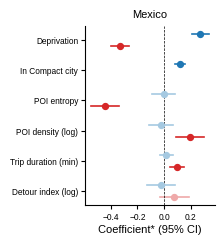

In [59]:
def lighten_color(color, amount=0.55):
    """
    Lighten a color by mixing it with white.
    amount: 0 -> original color, 1 -> white
    """
    c = mcolors.to_rgb(color)
    return tuple((1 - amount) * x + amount * 1.0 for x in c)

def plot_sdm_effects(df, country=None, show_legend=True, p_threshold=0.05):
    df = df.copy()

    desired_order = [
        "Deprivation",
        "In Compact city",
        "POI entropy",
        "POI density (log)",
        "Trip duration (min)",
        "Detour index (log)"
    ]

    df["Variable"] = pd.Categorical(
        df["Variable"],
        categories=desired_order,
        ordered=True
    )

    rows = []
    for _, r in df.iterrows():
        rows.append({
            "Variable": r["Variable"],
            "EffectType": "Direct",
            "Coefficient": r["Direct"],
            "Lower": r["Direct_lower"],
            "Upper": r["Direct_upper"],
            "PValue": r.get("Direct_pvalue", pd.NA)
        })

        if pd.notnull(r.get("Spillover")):
            rows.append({
                "Variable": r["Variable"],
                "EffectType": "Spillover",
                "Coefficient": r["Spillover"],
                "Lower": r["Spillover_lower"],
                "Upper": r["Spillover_upper"],
                "PValue": r.get("Spillover_pvalue", pd.NA)
            })

    long_df = pd.DataFrame(rows)
    long_df["Variable"] = pd.Categorical(
        long_df["Variable"],
        categories=desired_order,
        ordered=True
    )

    # significance flag
    long_df["Significant"] = long_df["PValue"].le(p_threshold)

    # base palette
    base_colors = {
        "Direct": "#1f77b4",
        "Spillover": "#d62728"
    }
    light_colors = {
        k: lighten_color(v, amount=0.6)
        for k, v in base_colors.items()
    }

    # color per row depending on significance
    long_df["PlotColor"] = long_df.apply(
        lambda r: base_colors[r["EffectType"]]
        if pd.isna(r["PValue"]) or r["Significant"]
        else light_colors[r["EffectType"]],
        axis=1
    )

    fig, ax = plt.subplots(figsize=(55/25.4, 60/25.4))

    # draw points manually for full color control
    offsets = {"Direct": -0.2, "Spillover": 0.2}

    for _, row in long_df.iterrows():
        var = row["Variable"]
        eff = row["EffectType"]
        y_base = desired_order.index(var)
        y_pos = y_base + offsets[eff]
        col = row["PlotColor"]

        # confidence interval
        ax.plot(
            [row["Lower"], row["Upper"]],
            [y_pos, y_pos],
            color=col,
            linewidth=1.2,
            zorder=2
        )

        # point estimate
        ax.scatter(
            row["Coefficient"],
            y_pos,
            color=col,
            s=18,
            zorder=3
        )

    ax.axvline(0, color="black", linestyle="--", linewidth=0.5)
    sns.despine(ax=ax)

    ax.set_yticks(range(len(desired_order)))
    ax.set_yticklabels(desired_order)
    ax.set_xlabel("Coefficient* (95% CI)")
    ax.set_ylabel("")

    if country is not None:
        ax.set_title(country.capitalize())

    if show_legend:
        from matplotlib.lines import Line2D
        legend_handles = [
            Line2D([0], [0], marker='o', color=base_colors["Direct"],
                   linestyle='None', markersize=5, label="Direct"),
            Line2D([0], [0], marker='o', color=base_colors["Spillover"],
                   linestyle='None', markersize=5, label="Spillover"),
            Line2D([0], [0], marker='o', color='gray',
                   alpha=0.45, linestyle='None', markersize=5,
                   label=f"p > {p_threshold}")
        ]
        ax.legend(handles=legend_handles, frameon=False)
    ax.invert_yaxis()
    fig.tight_layout(pad=0.6)

    if country is not None:
        fig.savefig(
            f"figures/slx_coef_{country}.pdf",
            dpi=600,
            facecolor="white"
        )

    plt.show()

plot_sdm_effects(effects_sdm_ready, country=country, show_legend=False)

### 2 Direct vs. spillover bar plot

In [189]:
# effects_sdm_ready contains the columns:
# Variable, Direct, Spillover (may include NaN for spillover-less vars)

df2plot = effects_sdm_ready.copy()

# Replace NaN spillovers with 0
df2plot['Spillover'] = df2plot['Spillover'].fillna(0)
df2plot['Direct'] = df2plot['Direct'].fillna(0)

# Absolute contributions
df2plot['Direct_abs'] = df2plot['Direct'].abs()
df2plot['Spillover_abs'] = df2plot['Spillover'].abs()

# Total contribution for each variable
df2plot['Total_abs'] = df2plot['Direct_abs'] + df2plot['Spillover_abs']

# Normalize to percentages
df2plot['Direct_share'] = df2plot['Direct_abs'] / df2plot['Total_abs']
df2plot['Spillover_share'] = df2plot['Spillover_abs'] / df2plot['Total_abs']

df_contrib = df2plot[['Variable', 'Direct_share', 'Spillover_share']]
df_contrib = df_contrib[df_contrib['Variable'] != 'In Compact city']  # drop dummy variable

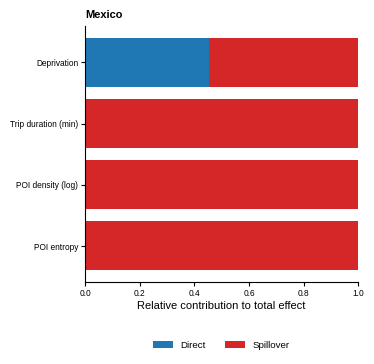

In [190]:
fig, ax = plt.subplots(
    nrows=1, ncols=1,
    figsize=(15/4, 15/4)
)
# Data in correct order (top-to-bottom)
df_plot = df_contrib.set_index("Variable").sort_values("Direct_share", ascending=True)

variables = df_plot.index

plt.barh(
    variables,
    df_plot["Direct_share"],
    color="#1f77b4",
    label="Direct"
)

plt.barh(
    variables,
    df_plot["Spillover_share"],
    left=df_plot["Direct_share"],
    color="#d62728",
    label="Spillover"
)

plt.xlabel("Relative contribution to total effect")
plt.legend(
        loc='lower center',
        bbox_to_anchor=(0.5, -0.3),
        ncol=2,
        frameon=False
    )
sns.despine()
plt.xlim(0, 1)
plt.title(country.capitalize(), loc='left', fontweight='bold')
plt.tight_layout()
fig.savefig(f"../figures/slx_effect_{country}.png", dpi=300, bbox_inches='tight')
plt.show()

### 3 Spillover intensity map

In [191]:
effects_sdm_ready

,Variable,Direct,Direct_lower,Direct_upper,Spillover,Spillover_lower,Spillover_upper
0,POI entropy,NaN,NaN,NaN,-0.443696,-0.548832,-0.338561
1,Deprivation,0.272589,0.207291,0.337887,-0.329163,-0.398037,-0.260288
2,In Compact city,0.119479,0.084835,0.154122,NaN,NaN,NaN
3,POI density (log),NaN,NaN,NaN,0.195408,0.091508,0.299308
4,Trip duration (min),NaN,NaN,NaN,0.098442,0.046176,0.150708


In [192]:
WX_df.columns

Index(['W_Entropy', 'W_log_POI_density', 'W_Residential', 'W_log_detour',
       'W_wm_duration_min'],
      dtype='object')

#### 3.1 All figures

In [193]:
# Mapping between effects_sdm_ready Variable names and WX_df columns
spillover_map = {
    "POI entropy": "W_Entropy",
    "Deprivation": "W_Residential",
    "POI density (log)": "W_log_POI_density",
    "Trip duration (min)": "W_wm_duration_min"
}
if country == 'india':
    spillover_map["Detour index (log)"] = "W_log_detour"
# Prepare output dictionary
spillover_outputs = {}

for var, wx_col in spillover_map.items():
    # 1. Extract spillover beta coefficient
    beta_sp = effects_sdm_ready.loc[
        effects_sdm_ready["Variable"] == var, "Spillover"
    ].values[0]
    
    # 2. Compute spillover contribution
    spillover_raw = WX_df[wx_col].values * beta_sp
    
    # 3. Normalize
    # spillover_norm = (spillover_raw - spillover_raw.mean()) / spillover_raw.std()
    spillover_norm = spillover_raw
    
    # 4. Store in df2m
    col_raw = f"spill_{wx_col}"
    col_norm = f"spill_{wx_col}_norm"
    
    df2m[col_raw] = spillover_raw
    df2m[col_norm] = spillover_norm
    
    spillover_outputs[var] = (col_raw, col_norm)

df2m.head()

,cell,detour,Empirical,Residential,threshold,Theoretical,Country,correct_name,bb_e,bb_t,...,compact_dummy,neighbors,spill_W_Entropy,spill_W_Entropy_norm,spill_W_Residential,spill_W_Residential_norm,spill_W_log_POI_density,spill_W_log_POI_density_norm,spill_W_wm_duration_min,spill_W_wm_duration_min_norm
0,874995b86ffffff,1.210166,9.949130,12.554252,45 min,11.706087,mexico,Greater Mexico City,2.605122,0.848165,...,0,"{874995b95ffffff, 874995b80ffffff, 874995b82ff...",-1.747903,-1.747903,-2.978349,-2.978349,-1.077245,-1.077245,4.818266,4.818266
1,874995bb1ffffff,1.223314,10.172453,8.820479,45 min,10.781191,mexico,Greater Mexico City,-1.351973,-1.960712,...,0,"{874995bb0ffffff, 874995b86ffffff, 874995bb5ff...",-1.760210,-1.760210,-3.116837,-3.116837,-1.018484,-1.018484,4.793071,4.793071
2,874995ba6ffffff,1.207564,8.292169,6.710177,45 min,9.559123,mexico,Greater Mexico City,-1.581992,-2.848946,...,0,"{874995ba0ffffff, 874995859ffffff, 87499585bff...",-1.824510,-1.824510,-2.367165,-2.367165,-0.954581,-0.954581,4.845449,4.845449
3,874995ba2ffffff,1.208923,9.137159,8.479541,45 min,10.119233,mexico,Greater Mexico City,-0.657618,-1.639692,...,0,"{874995ba0ffffff, 874995ba6ffffff, 874995ba3ff...",-1.792387,-1.792387,-2.679465,-2.679465,-0.872717,-0.872717,4.683287,4.683287
4,874995bb5ffffff,1.241095,8.733309,8.058673,45 min,10.156311,mexico,Greater Mexico City,-0.674637,-2.097638,...,0,"{874995bb0ffffff, 874995ba6ffffff, 874995bb4ff...",-1.759232,-1.759232,-2.731339,-2.731339,-1.077823,-1.077823,5.116742,5.116742


In [194]:
extra_vars = ['bb_g', 'Entropy', 'Residential', 'log_POI_density', 'wm_duration_min', 'log_detour']
var_list = [f'spill_{var}_norm' for var in list(spillover_map.values())] + extra_vars
var_list

['spill_W_Entropy_norm',
 'spill_W_Residential_norm',
 'spill_W_log_POI_density_norm',
 'spill_W_wm_duration_min_norm',
 'bb_g',
 'Entropy',
 'Residential',
 'log_POI_density',
 'wm_duration_min',
 'log_detour']

In [195]:
var_list_dict = {'spill_W_Entropy_norm': 'POI entropy spillover',
                'spill_W_Residential_norm': 'Deprivation spillover',
                'spill_W_log_POI_density_norm': 'POI density spillover',
                'spill_W_wm_duration_min_norm': 'Trip duration spillover',
                'spill_W_log_detour_norm': 'Detour index spillover',
                'bb_g': 'Residual bubble breaking',
                'Entropy': 'POI entropy',
                'Residential': 'Deprivation',
                'log_POI_density': 'POI density (log)',
                'wm_duration_min': 'Trip duration (min)',
                'log_detour': 'Detour index (log)'}

if country == 'india':
    var_order = ['Deprivation', 'Deprivation spillover', 
                'POI entropy', 'POI entropy spillover', 
                'POI density (log)', 'POI density spillover', 
                'Trip duration (min)', 'Trip duration spillover', 
                'Detour index (log)', 'Detour index spillover', 'Residual bubble breaking']
else:
    var_order = ['Deprivation', 'Deprivation spillover', 
                'POI entropy', 'POI entropy spillover', 
                'POI density (log)', 'POI density spillover', 
                'Trip duration (min)', 'Trip duration spillover', 
                'Detour index (log)', 'Residual bubble breaking']

In [196]:
def city_spillover_data(var_list=None, city=None):
    df2plot = gdf[['cell', 'correct_name', 'country', 'geometry']].merge(
            df2m[['cell'] + var_list],
            left_on='cell',
            right_on='cell',
            how='left'
    )
    df2plot.dropna(subset=var_list, inplace=True)
    df2plot = df2plot[df2plot['correct_name'] == city].copy()
    return df2plot

df2plot = city_spillover_data(var_list=var_list, city='Greater Mexico City')
df2plot.rename(columns=var_list_dict, inplace=True)
df2plot = df2plot[['cell', 'correct_name', 'country'] + var_order + ['geometry']]

In [197]:
def _get_norm(vmin, vmax):
    # Handle trivial case
    if vmin == vmax:
        return mpl.colors.Normalize(vmin=vmin - 1e-6, vmax=vmax + 1e-6)

    # Case 1: crosses zero → use diverging scale
    if vmin < 0 < vmax:
        return mpl.colors.TwoSlopeNorm(vmin=vmin, vcenter=0, vmax=vmax)

    # Case 2: entirely positive → expand slight negative padding
    if vmin >= 0:
        padded_vmin = -0.001
        return mpl.colors.TwoSlopeNorm(vmin=padded_vmin, vcenter=0, vmax=vmax)

    # Case 3: entirely negative → expand slight positive padding
    if vmax <= 0:
        padded_vmax = 0.001
        return mpl.colors.TwoSlopeNorm(vmin=vmin, vcenter=0, vmax=padded_vmax)

    # Default fallback
    return mpl.colors.Normalize(vmin=vmin, vmax=vmax)

def plot_spillover_panels(df2plot, city_label, savepath=None):
    """
    Plot local and spillover variables with:
    - Per-subplot colorbars
    - Single cached basemap (fast)
    - Clean blank subplots
    """

    import contextily as ctx

    # ----------------------------------------------------------
    # Variable order
    # ----------------------------------------------------------
    var_order = [
        'Deprivation', 'Deprivation spillover', 
        'POI entropy', 'POI entropy spillover', 
        'POI density (log)', 'POI density spillover', 
        'Trip duration (min)', 'Trip duration spillover', 
        'Detour index (log)', 'Residual bubble breaking'
    ]

    # ----------------------------------------------------------
    # Setup figure
    # ----------------------------------------------------------
    n = len(var_order)
    ncols = 4
    nrows = int(np.ceil(n / ncols))

    fig, axes = plt.subplots(nrows, ncols, figsize=(12, 10), dpi=300)
    axes = axes.flatten()

    # ----------------------------------------------------------
    # Prepare spatial extent (square box)
    # ----------------------------------------------------------
    xmin, ymin, xmax, ymax = df2plot.total_bounds
    pad = 1000
    xmin, ymin, xmax, ymax = xmin-pad, ymin-pad, xmax+pad, ymax+pad

    width, height = xmax-xmin, ymax-ymin
    if width > height:
        d = (width - height)/2
        ymin -= d
        ymax += d
    else:
        d = (height - width)/2
        xmin -= d
        xmax += d

    extent = (xmin, xmax, ymin, ymax)

    # ----------------------------------------------------------
    # FAST: Pre-download basemap only once
    # ----------------------------------------------------------
    basemap_img, basemap_ext = ctx.bounds2img(
        xmin, ymin, xmax, ymax,
        zoom=12,
        source=ctx.providers.CartoDB.Voyager
    )

    # ----------------------------------------------------------
    # Loop through variables
    # ----------------------------------------------------------
    cmap = "RdYlBu_r"

    for ax, colname in zip(axes, var_order):

        # Completely blank subplot if variable missing
        if colname not in df2plot.columns:
            ax.set_facecolor("white")
            ax.axis("off")
            ax.set_title(colname, fontsize=8, loc='left', fontweight='bold')
            continue

        # Compute normalization
        vmin, vmax = df2plot[colname].quantile([0.05, 0.95])
        # Determine the appropriate normalization

        # --- Usage inside your plotting code ---
        if "spillover" in colname.lower():
            norm = _get_norm(vmin, vmax)
        else:
            norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)

        # BASEMAP (already cached)
        ax.imshow(basemap_img, extent=basemap_ext, interpolation='bilinear')

        # PLOT THE VARIABLE
        df2plot.plot(
            column=colname, ax=ax,
            cmap=cmap, norm=norm,
            alpha=0.85, linewidth=0.3, edgecolor="white",
            legend=False
        )

        # Clean formatting
        ax.set_xlim(extent[0], extent[1])
        ax.set_ylim(extent[2], extent[3])
        ax.set_aspect("equal")
        ax.set_title(colname, fontsize=7, loc='left', fontweight='bold')
        ax.axis("off")

        # ----------------------------
        # PER-SUBPLOT COLORBAR
        # ----------------------------
        sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
        # ----- Horizontal colorbar above each subplot -----
        # Compute panel bounding box in figure coordinates
        bbox = ax.get_position()

        # Create a new inset axis ABOVE the subplot
        cax = fig.add_axes([
            bbox.x0,          # same left position
            bbox.y0 - 0.02,  # a little above the subplot
            bbox.width,       # same width as subplot
            0.015             # height of the colorbar strip
        ])

        cbar = fig.colorbar(sm, cax=cax, orientation="horizontal")

        # Clean styling
        cbar.outline.set_visible(False)
        cbar.ax.tick_params(labelsize=6, length=2, pad=1)

        # optional: remove label entirely
        cbar.set_label("")

    # After looping over variables, clean any remaining empty axes
    for ax in axes[len(var_order):]:
        ax.cla()                    # clear anything inside the axis
        ax.set_facecolor("white")   # pure white background
        ax.set_xticks([])           # remove ticks
        ax.set_yticks([])           
        for spine in ax.spines.values():
            spine.set_visible(False)
        ax.axis("off")              # guarantees nothing is drawn
    # ----------------------------------------------------------
    # TITLE + SAVE
    # ----------------------------------------------------------
    fig.suptitle(f"{city_label}", fontsize=12, fontweight='bold', y=0.95)
    # plt.tight_layout(rect=[0, 0, 0.93, 0.96])

    if savepath:
        fig.savefig(savepath, dpi=300, bbox_inches="tight")
        plt.close()
    else:
        plt.show()

# city_label = "Greater Mexico City"
# plot_spillover_panels(df2plot=df2plot.to_crs(3857), city_label=city_label, savepath=f'../figures/spillover_cities/mexico/{city_label}.png')

In [22]:
city_list = df2m.correct_name.unique()

for c in city_list:
    
    save_path = f'../figures/spillover_cities/{country}/{c}.png'
    
    # --- Skip if file already exists ---
    if os.path.exists(save_path):
        print(f"⏭️  Skipping {c}: file already exists.")
        continue

    # Prepare data
    df2plot = city_spillover_data(var_list=var_list, city=c)
    df2plot.rename(columns=var_list_dict, inplace=True)
    df2plot = df2plot[['cell', 'correct_name', 'country'] + var_order + ['geometry']]
    
    # Plot + Save
    plot_spillover_panels(
        df2plot=df2plot.to_crs(3857),
        city_label=c,
        savepath=save_path
    )
    print(f"✅ Saved: {save_path}")

✅ Saved: ../figures/spillover_cities/india/Pune.png
✅ Saved: ../figures/spillover_cities/india/Kolkata.png
✅ Saved: ../figures/spillover_cities/india/Bangalore.png
✅ Saved: ../figures/spillover_cities/india/New Delhi.png
✅ Saved: ../figures/spillover_cities/india/Chandigarh.png
✅ Saved: ../figures/spillover_cities/india/Chennai.png
✅ Saved: ../figures/spillover_cities/india/Hyderabad.png
✅ Saved: ../figures/spillover_cities/india/Bhopal.png
✅ Saved: ../figures/spillover_cities/india/Ahmadabad.png
✅ Saved: ../figures/spillover_cities/india/Vadodara.png
✅ Saved: ../figures/spillover_cities/india/Indore.png
✅ Saved: ../figures/spillover_cities/india/Thane.png
✅ Saved: ../figures/spillover_cities/india/Coimbatore.png
✅ Saved: ../figures/spillover_cities/india/Nagpur.png
✅ Saved: ../figures/spillover_cities/india/Jaipur.png
✅ Saved: ../figures/spillover_cities/india/Surat.png
✅ Saved: ../figures/spillover_cities/india/Bhubaneswar.png
✅ Saved: ../figures/spillover_cities/india/Visakhapatnam.

#### 3.2 Manuscript figures
##### Residential deprivation

In [198]:
# 1. Extract spillover coefficient for Residential
beta_W_res = effects_sdm_ready.loc[
    effects_sdm_ready['Variable'] == 'Deprivation',
    'Spillover'
].values[0]

print("Spillover coefficient (W_Residential):", beta_W_res)

# 2. Spillover term: WX * beta
df2m['spillover_residential'] = WX_df['W_Residential'].values * beta_W_res
df2m['spillover_residential_norm'] = (
    df2m['spillover_residential'] - df2m['spillover_residential'].mean()
) / df2m['spillover_residential'].std()
df2m[['cell', 'spillover_residential', 'spillover_residential_norm']].head()

Spillover coefficient (W_Residential): -0.3291628076390848


,cell,spillover_residential,spillover_residential_norm
0,874995b86ffffff,-2.978349,2.262895
1,874995bb1ffffff,-3.116837,2.207616
2,874995ba6ffffff,-2.367165,2.506858
3,874995ba2ffffff,-2.679465,2.382199
4,874995bb5ffffff,-2.731339,2.361493


In [199]:
def plot_spillover_map(
    var="deprivation",
    column="spillover_residential_norm",
    title=None,
    label_city=True,
    figsize_mm=45,
    zoom=12,
    pad_m=1000,
    cbar_label="Spillover intensity"
):
    city_dict = {"india": "New Delhi", "mexico": "Greater Mexico City"}

    # --- build plotting gdf ---
    df2plot = gdf[["cell", "correct_name", "country", "geometry"]].merge(
        df2m[["cell", column]],
        on="cell",
        how="left"
    )
    df2plot = df2plot.dropna(subset=[column])
    df2plot = df2plot[df2plot["correct_name"] == city_dict[country]].copy()
    df2plot = df2plot.to_crs(epsg=3857)

    # --- color scale ---
    vmin, vmax = df2plot[column].quantile([0.05, 0.95])
    norm = TwoSlopeNorm(vmin=vmin, vcenter=0, vmax=vmax)
    cmap = "RdYlBu_r"

    # --- square extent ---
    xmin, ymin, xmax, ymax = df2plot.total_bounds
    xmin, ymin, xmax, ymax = xmin - pad_m, ymin - pad_m, xmax + pad_m, ymax + pad_m
    w, h = (xmax - xmin), (ymax - ymin)
    if w > h:
        d = (w - h) / 2
        ymin -= d
        ymax += d
    else:
        d = (h - w) / 2
        xmin -= d
        xmax += d

    # --- fixed-size figure (45 mm x 45 mm) ---
    fig, ax = plt.subplots(figsize=(figsize_mm / 25.4, figsize_mm / 25.4), dpi=300)

    # Reserve a right strip for the colorbar INSIDE the page
    # (no artist should go outside the figure)
    fig.subplots_adjust(left=0.05, right=0.86, bottom=0.05, top=0.92)

    # --- plot polygons ---
    df2plot.plot(
        column=column,
        ax=ax,
        legend=False,
        cmap=cmap,
        norm=norm,
        alpha=0.7,
        edgecolor="none",
        zorder=3
    )

    # --- set extent & basemap ---
    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ymin, ymax)
    ax.set_aspect("equal", "box")

    ctx.add_basemap(ax, source=ctx.providers.CartoDB.Voyager, zoom=zoom, zorder=0)

    # --- shrink basemap attribution (if present) ---
    for artist in ax.texts:
        if "OpenStreetMap" in artist.get_text():
            artist.set_fontsize(3)
            artist.set_alpha(0.3)
            artist.set_fontstyle("italic")

    # # --- title INSIDE axes (so it cannot spill outside) ---
    # if title is not None:
    #     ax.text(
    #         0.5, 0.99, title,
    #         transform=ax.transAxes,
    #         ha="center", va="top",
    #         fontsize=8,
    #         bbox=dict(facecolor="white", alpha=0.85, edgecolor="none", boxstyle="round,pad=0.2")
    #     )
    if title is not None:
        ax.set_title(title)
    # --- optional city label (keep INSIDE axes, not outside) ---
    if label_city:
        ax.text(
            0.02, 0.5, city_dict[country],
            transform=ax.transAxes,
            rotation=90,
            ha="left", va="center",
            fontsize=7,
            bbox=dict(facecolor="white", alpha=0.75, edgecolor="none", pad=1)
        )

    ax.axis("off")

    # --- colorbar attached to axis (NO fig.add_axes) ---
    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="5%", pad=0.05)  # created inside reserved right strip

    sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
    sm.set_array([])  # avoids a matplotlib warning in some versions

    cbar = fig.colorbar(sm, cax=cax, orientation="vertical")
    cbar.set_label(cbar_label)
    cbar.outline.set_visible(False)

    fig.savefig(f"../figures/slx_intensity_{country}_{var}.pdf", dpi=600, facecolor="white")
    plt.show()
    return fig, ax

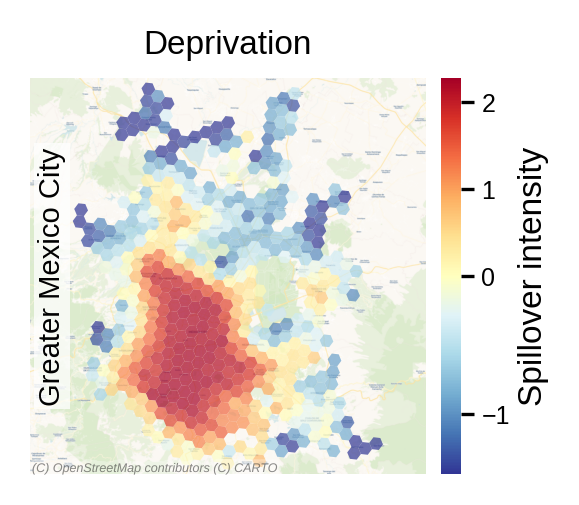

(<Figure size 531.496x531.496 with 2 Axes>,
 <Axes: title={'center': 'Deprivation'}>)

In [200]:
plot_spillover_map(var='deprivation', column='spillover_residential_norm', title='Deprivation', label_city=True)

##### POI density

In [201]:
# 1. Extract spillover coefficient for Residential
beta_W_res = effects_sdm_ready.loc[
    effects_sdm_ready['Variable'] == 'POI density (log)',
    'Spillover'
].values[0]

print("Spillover coefficient (W_POI density):", beta_W_res)

# 2. Spillover term: WX * beta
df2m['spillover_density'] = WX_df['W_log_POI_density'].values * beta_W_res
df2m['spillover_density_norm'] = (
    df2m['spillover_density'] - df2m['spillover_density'].mean()
) / df2m['spillover_density'].std()
df2m[['cell', 'spillover_density', 'spillover_density_norm']].head()

Spillover coefficient (W_POI density): 0.1954080237123456


,cell,spillover_density,spillover_density_norm
0,874995b86ffffff,-1.077245,1.549568
1,874995bb1ffffff,-1.018484,1.830741
2,874995ba6ffffff,-0.954581,2.136513
3,874995ba2ffffff,-0.872717,2.528231
4,874995bb5ffffff,-1.077823,1.546802


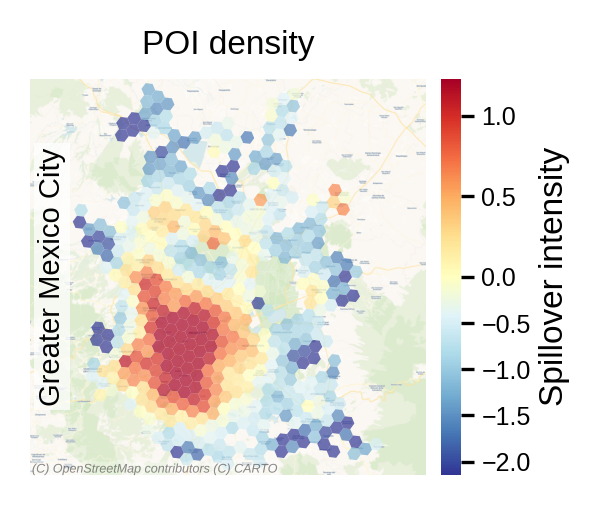

(<Figure size 531.496x531.496 with 2 Axes>,
 <Axes: title={'center': 'POI density'}>)

In [202]:
plot_spillover_map(var='density', column='spillover_density_norm', title='POI density', label_city=True)

##### POI diversity

In [203]:
# 1. Extract spillover coefficient for Residential
beta_W_res = effects_sdm_ready.loc[
    effects_sdm_ready['Variable'] == 'POI entropy',
    'Spillover'
].values[0]

print("Spillover coefficient (W_POI entropy):", beta_W_res)

# 2. Spillover term: WX * beta
df2m['spillover_entropy'] = WX_df['W_Entropy'].values * beta_W_res
df2m['spillover_entropy_norm'] = (
    df2m['spillover_entropy'] - df2m['spillover_entropy'].mean()
) / df2m['spillover_entropy'].std()
df2m[['cell', 'spillover_entropy', 'spillover_entropy_norm']].head()

Spillover coefficient (W_POI entropy): -0.4436964516184615


,cell,spillover_entropy,spillover_entropy_norm
0,874995b86ffffff,-1.747903,-1.229880
1,874995bb1ffffff,-1.760210,-1.264588
2,874995ba6ffffff,-1.824510,-1.445920
3,874995ba2ffffff,-1.792387,-1.355329
4,874995bb5ffffff,-1.759232,-1.261830


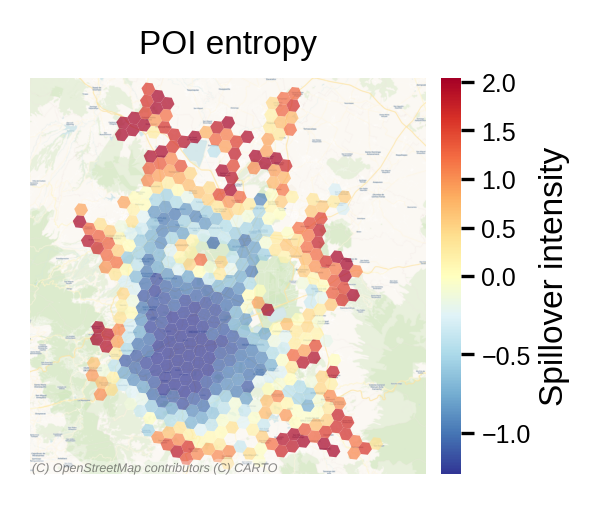

(<Figure size 531.496x531.496 with 2 Axes>,
 <Axes: title={'center': 'POI entropy'}>)

In [204]:
plot_spillover_map(var='entropy', column='spillover_entropy_norm', title='POI entropy', label_city=False)

### 4 Marginal effects across deprivation bins etc (d)

In [205]:
effects_sdm_ready
# Replace NaN spillovers with 0
effects_sdm_ready['Spillover'] = effects_sdm_ready['Spillover'].fillna(0)
effects_sdm_ready['Direct'] = effects_sdm_ready['Direct'].fillna(0)

In [206]:
def marginal_effects_data(
    effects_sdm_ready=None,
    WX_df=None,
    df2m=None,
    num_grp=10,
    x_var="Residential",
    y_var_d2m="Entropy",
    y_var_sdm="POI entropy"
):
    """
    Computes direct, spillover, and total marginal effects of y_var_d2m,
    binned across x_var (e.g., deprivation).
    """

    # Extract SLX coefficients
    beta_dir = effects_sdm_ready.loc[
        effects_sdm_ready['Variable'] == y_var_sdm, 'Direct'
    ].values[0]
    if y_var_sdm != 'In Compact city':
        beta_sp = effects_sdm_ready.loc[
            effects_sdm_ready['Variable'] == y_var_sdm, 'Spillover'
        ].values[0]
    else:
        beta_sp = 0.0   # no spillover for dummy variable

    temp = df2m.copy()

    # Compute each marginal component
    temp[f'Direct_{y_var_d2m}']    = temp[y_var_d2m].values * beta_dir
    if y_var_sdm != 'In Compact city':
        temp[f'Spill_{y_var_d2m}']     = WX_df[f"W_{y_var_d2m}"].values * beta_sp
    else:
        temp[f'Spill_{y_var_d2m}']     = 0.0
    temp[f'Total_{y_var_d2m}']     = temp[f'Direct_{y_var_d2m}'] + temp[f'Spill_{y_var_d2m}']

    # Deprivation bins
    temp['grp_cell'] = pd.qcut(
        temp[x_var],
        q=num_grp,
        labels=[i for i in range(1, num_grp + 1)]
    ).astype(float)

    # Bootstrap statistics
    def grp_stats(data):
        # Compute bootstrap medians and errors for each component
        md_dir, md_dir_err = bootstrap_median(data[f'Direct_{y_var_d2m}'], n_bootstrap=1000)
        md_sp,  md_sp_err  = bootstrap_median(data[f'Spill_{y_var_d2m}'],  n_bootstrap=1000)
        md_tot, md_tot_err = bootstrap_median(data[f'Total_{y_var_d2m}'],  n_bootstrap=1000)

        return pd.Series({
            "r": data[x_var].median(),
            f"Direct50": md_dir, 
            f"Direct_err": md_dir_err,
            f"Spill50": md_sp,
            f"Spill_err": md_sp_err,
            f"Total50": md_tot,
            f"Total_err": md_tot_err
        })
    
    marg = temp.groupby('grp_cell', observed=True).apply(
        grp_stats, include_groups=False
    ).reset_index()
    marg.loc[:, 'y_var'] = y_var_sdm
    return marg

In [207]:
def plot_marginal_effects(marg_dataframe=None, var=None):

    x = marg_dataframe['r'].values

    # Colors
    color_direct = "#1f77b4"
    color_spill  = "#d62728"
    color_total  = "#495d6a"

    fig, ax1 = plt.subplots(figsize=(45/25.4, 45/25.4))

    # ----------------------------------------------------
    # LEFT AXIS — Direct & Spillover
    # ----------------------------------------------------
    ax1.set_xlabel("Deprivation")
    ax1.set_ylabel("Direct / Spillover effect")

    # --- Direct ---
    line_direct, = ax1.plot(
        x, marg_dataframe['Direct50'], color=color_direct,
        marker='o', label="Direct", markersize=4
    )
    ax1.fill_between(
        x,
        marg_dataframe['Direct50'] - marg_dataframe['Direct_err'],
        marg_dataframe['Direct50'] + marg_dataframe['Direct_err'],
        color=color_direct, alpha=0.12, linewidth=0
    )

    # --- Spillover ---
    line_spill, = ax1.plot(
        x, marg_dataframe['Spill50'], color=color_spill,
        marker='o', label="Spillover", markersize=4
    )
    ax1.fill_between(
        x,
        marg_dataframe['Spill50'] - marg_dataframe['Spill_err'],
        marg_dataframe['Spill50'] + marg_dataframe['Spill_err'],
        color=color_spill, alpha=0.12, linewidth=0
    )

    # ----------------------------------------------------
    # RIGHT AXIS — Total
    # ----------------------------------------------------
    ax2 = ax1.twinx()
    ax2.set_ylabel("Total effect", color=color_total)
    ax2.tick_params(axis='y', labelcolor=color_total)

    line_total, = ax2.plot(
        x, marg_dataframe['Total50'], color=color_total,
        marker='o', linestyle='-', label="Total", markersize=4
    )
    ax2.fill_between(
        x,
        marg_dataframe['Total50'] - marg_dataframe['Total_err'],
        marg_dataframe['Total50'] + marg_dataframe['Total_err'],
        color=color_total, alpha=0.12, linewidth=0
    )

    # # ----------------------------------------------------
    # # Combined legend (from both axes)
    # # ----------------------------------------------------
    # lines = [line_direct, line_spill, line_total]
    # labels = ["Direct", "Spillover", "Total"]
    # ax1.legend(
    #     lines, labels,
    #     loc="upper center", ncol=3, 
    #     bbox_to_anchor=(0.5, 1.4)
    # )

    # ----------------------------------------------------
    # Final formatting
    # ----------------------------------------------------
    sns.despine(ax=ax1)
    sns.despine(ax=ax2, left=True, right=False)

    plt.title(country.capitalize())
    fig.tight_layout(pad=0.6)

    fig.savefig(f"../figures/slx_marginal_{country}_{var}.pdf",
                dpi=600)
    plt.show()

In [208]:
marg_entropy = marginal_effects_data(effects_sdm_ready=effects_sdm_ready, WX_df=WX_df, df2m=df2m, num_grp=10, x_var="Residential", y_var_d2m="Entropy", y_var_sdm="POI entropy")
marg_density = marginal_effects_data(effects_sdm_ready=effects_sdm_ready, WX_df=WX_df, df2m=df2m, num_grp=10, x_var="Residential", y_var_d2m="log_POI_density", y_var_sdm="POI density (log)")
marg_deprivation = marginal_effects_data(effects_sdm_ready=effects_sdm_ready, WX_df=WX_df, df2m=df2m, num_grp=10, x_var="Residential", y_var_d2m="Residential", y_var_sdm="Deprivation")

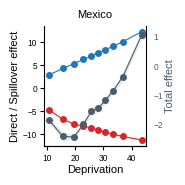

In [209]:
plot_marginal_effects(marg_dataframe=marg_deprivation, var='deprivation')